### Questions of Interest
* The bucket sizes Simmons uses were an arbitrary decision that was derived from the concept of reducing variation to reduce waste. How many buckets should Simmons be using and what sizes should the buckets be?
* Given Simmons target to eventually hit 75% upgrade, what "acceptable trim percentage" should be considered for determining bucket sizes?
* Simmons has expressed that they are hesitant to increase the probability of miscuts because they do not currently have the capacity to handle large amounts. Is there an acceptable tradeoff between trim and miscuts that will minimize yield? Is this path worth exploring?

# How do we account for the variation of weights in bucket size for calculating waste?

This dataset outlines three days worth of measurements from the x-ray machines on the processing line from Simmons poultry processing facility in Gentry, AR. The machines measure the weight (in pounds) of individual chicken breasts before they are sent to portioning facilities. The dataset contains three distributions: trim (small offcuts that mistakenly end up on the breast conveyors), single breasts, and butterflies (both breasts removed from the bird in one piece).

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

from scipy.stats import norm
from scipy.signal import argrelextrema
from scipy import integrate
from scipy.stats import kstest

In [43]:
# ingest data
df = pd.DataFrame(pd.read_csv('C:/Users/evanb/Documents/GitHub/simmons-portioning-tool/data/piecewise_data1.csv'))
df[['Weight (g)']] = df[['Weight (lb)']] * 453.592 # convert lbs to grams
x = df[['Weight (g)']].values
print("num records: ", df.shape[0])
df.head()

num records:  530000


,Material,Weight (lb),Piece type,PO,Shift,Batch,Grader,Gate number,Log time,Record type,Weight (g)
0,Wendy's,0.895352,NaN,NaN,Shift 3,NaN,SmartSort L 3-4,1,1/29/2026 23:45,1,406.124731
1,Medium,1.333424,NaN,NaN,Shift 3,NaN,SmartSort L 13-14,3,1/29/2026 23:45,1,604.830459
2,Large,1.251132,NaN,NaN,Shift 3,NaN,SmartSort L 11-12,2,1/29/2026 23:45,1,567.503466
3,Wendy's,0.934253,NaN,NaN,Shift 3,NaN,SmartSort L 1-2,1,1/29/2026 23:45,1,423.769732
4,Large,1.069108,NaN,NaN,Shift 3,NaN,SmartSort L 7-8,2,1/29/2026 23:45,1,484.938836


C:\Users\evanb\AppData\Local\Temp\ipykernel_8248\44400040.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


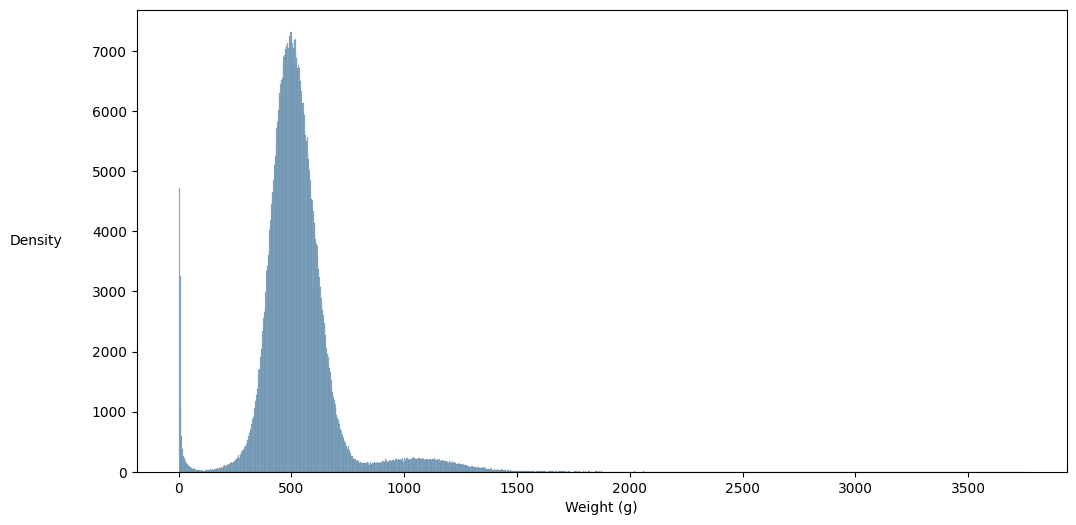

In [44]:
plt.figure(figsize=(12, 6))
sns.histplot(x, color='steelblue')

plt.xlabel("Weight (g)")
plt.ylabel("Density", rotation=0, labelpad=40, va='center')
plt.legend().remove()
plt.show()

## Identify Minima of Interest
We are interested in the weights of single chicken breasts. The first step in preprocessing this dataset is to identify the bounds of my distribution of interest. To do that I need to find the minima surrounding this distribution.

C:\Users\evanb\AppData\Local\Temp\ipykernel_8248\3642559989.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


<Figure size 1200x600 with 0 Axes>

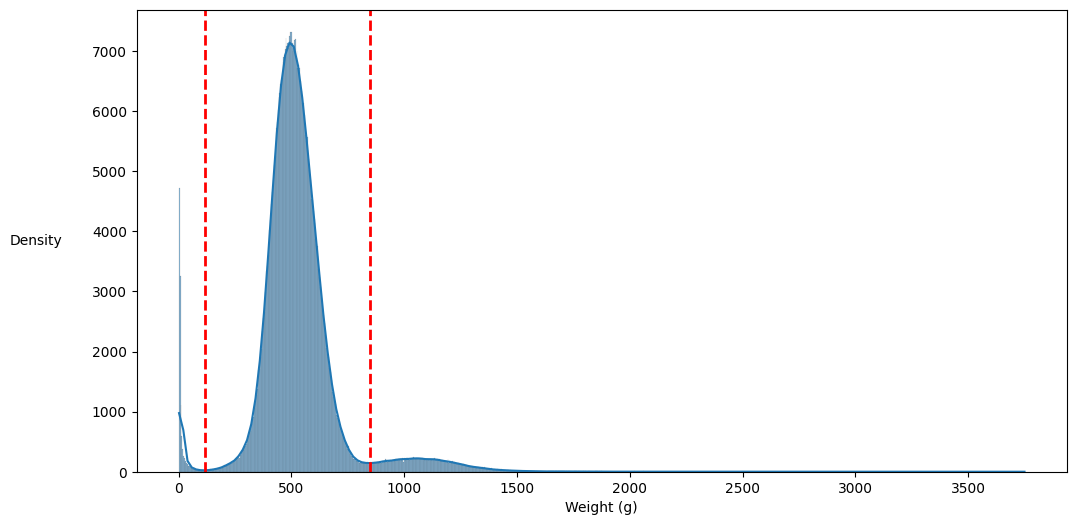

In [45]:
plt.figure(figsize=(12, 6))
kde_plot = sns.kdeplot(x, bw_adjust=1, fill=False, linewidth=2, color='black')

# Extract KDE curve data
xs, ys = kde_plot.get_lines()[0].get_data()

# Find local minima (valleys)
minima_idx = argrelextrema(ys, np.less)[0]
split_points = xs[minima_idx[:2]]
left, right = split_points[0], split_points[1]

# Plot histogram + KDE + split points
plt.clf()  # clear previous figure

plt.figure(figsize=(12, 6))
sns.histplot(x, kde=True, color='steelblue', alpha=0.5)

# Add split point lines
for sp in split_points:
    plt.axvline(sp, color='red', linestyle='--', linewidth=2)

# plt.title(f"Split points at density minima: {split_points}")
plt.xlabel("Weight (g)")
plt.ylabel("Density", rotation=0, labelpad=40, va='center')
plt.legend().remove()
plt.show()

## Fit Normal Distribution
After finding the minima of the distribution, I can trim the unnecessary data and begin fitting distributions to the dataset.

AttributeError: 'function' object has no attribute 'remove'

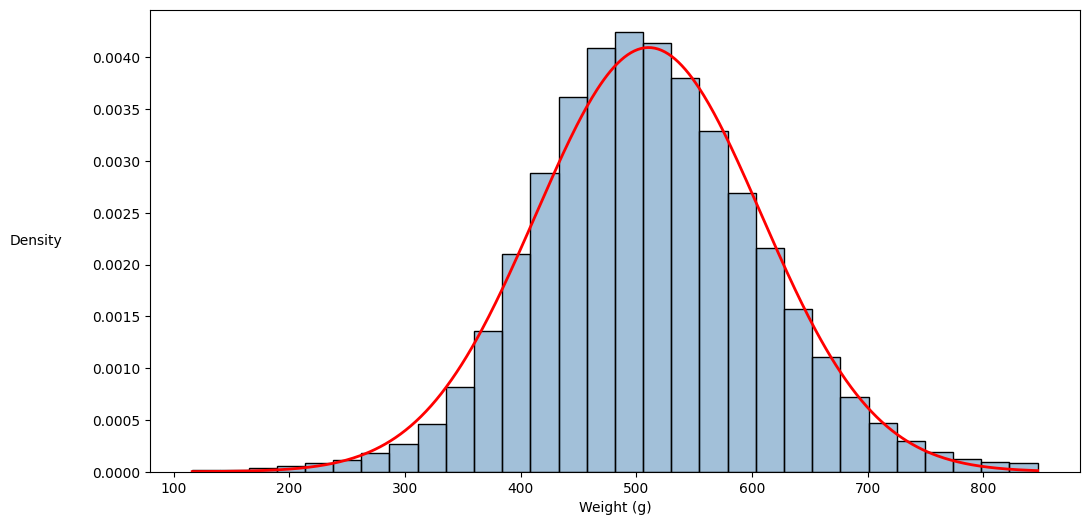

In [46]:
# Trim data between upper and lower bound
trimmed = x[(x >= left) & (x <= right)]

# Fit a normal distribution
mu, sigma = norm.fit(trimmed)

# Plot trimmed data + fitted normal curve
plt.figure(figsize=(12, 6))

# Histogram of trimmed data
sns.histplot(trimmed, bins=30, stat='density', color='steelblue', alpha=0.5)

# Normal curve
x_fit = np.linspace(trimmed.min(), trimmed.max(), 500)
normPDF = norm.pdf(x_fit, mu, sigma)
plt.plot(x_fit, normPDF, 'r-', linewidth=2, label='Fitted Normal')

# plt.title(f"Fitted Normal: mean = {mu:.3f}, sigma = {sigma:.3f}")
plt.xlabel("Weight (g)")
plt.ylabel("Density", rotation=0, labelpad=40, va='center')
plt.legend.remove()
plt.show()

## Fit Skewed Normal Distribution
After fitting the normal distribution, the histogram looked to me like it had a slight right skew to it. Taking the same data and using the same package, I fit the skewed normal distribution.

C:\Users\evanb\AppData\Local\Temp\ipykernel_8248\4151016903.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


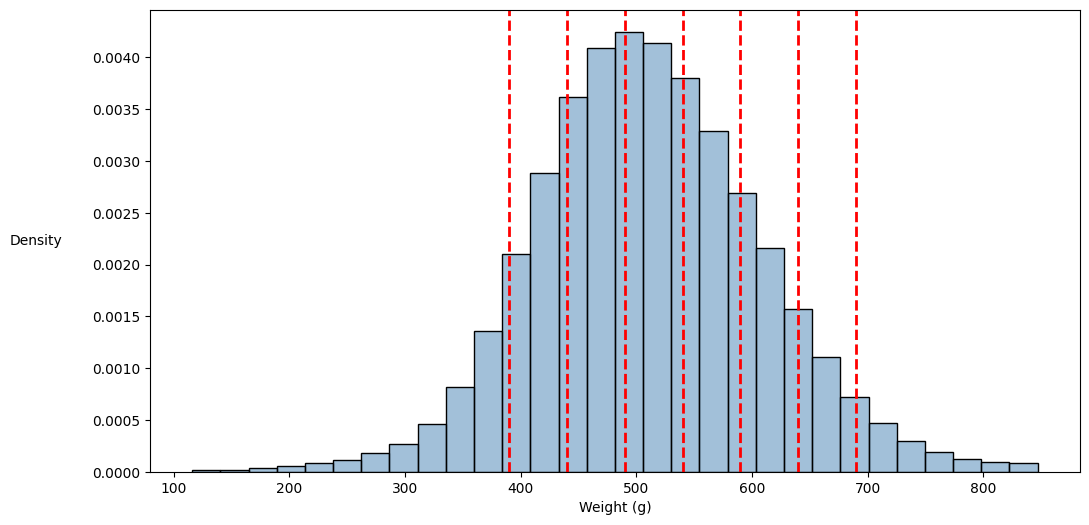

In [47]:
# Define split points
split_points = [390, 440, 490, 540, 590, 640, 690]

# Example plot — replace with whatever visualization you prefer
plt.figure(figsize=(12, 6))
sns.histplot(trimmed, bins=30, stat='density', color='steelblue', alpha=0.5)

# Draw vertical lines
for sp in split_points:
    plt.axvline(x=sp, color='red', linestyle='--', linewidth=2)

# plt.title("Bucket Ranges as Vertical Split Points")
plt.xlabel("Weight (g)")
plt.ylabel("Density", rotation=0, labelpad=40, va='center')
plt.legend().remove()
plt.show()

## Compare Fits
To compare the fits of the two distributions I calculated the MSE and found that the difference between the two was negligible. For simplicity's sake, I will continue using the normal distribution for future analysis.

In [48]:
kstest(trimmed, norm.cdf(x_fit, mu, sigma))

KstestResult(statistic=np.float64(1.0), pvalue=np.float64(0.0), statistic_location=np.float64(0.9997212037738825), statistic_sign=np.int8(-1))

# What is the average unavoidable trim for each bucket size?
Simmons would like us to target the lower bound of the weight bucket when making portioning decisions in order to minimize miscuts. When targeting the lower bound, there is a proportion of meat in each breast that is inevitably lost from breasts any larger than the absolute minimum. I want to explore what exactly that amount of waste is to see if modified bucket sizes or a different target weight rule could make a significant impact on the total waste of any given portioning decision.

### Expected Value of a Truncated Normal Distribution

$$ E[X] = \mu + \sigma\frac{\phi(\frac{a-\mu}{\sigma}) - \phi(\frac{b-\mu}{\sigma})}{\Phi(\frac{b-\mu}{\sigma}) - \Phi(\frac{a-\mu}{\sigma})}$$

Where
 * $\phi =$ The standard normal PDF
 * $\Phi =$ The standard normal CDF
 * $a,b = lb,ub$ of bucket range


In [49]:
def expected_x(a, b, mu, sigma):
    alpha = (a - mu)/sigma
    beta = (b - mu)/sigma
    mean = mu + sigma*((norm.pdf(alpha)-norm.pdf(beta))/(norm.cdf(beta)-norm.cdf(alpha)))
    return (mean - a) / mean

print(expected_x(440, 490, mu, sigma))

0.05577636433716795


### Estimating Breast Weight using Monte Carlo Simulation
My next step was to define a function that would preform a Monte Carlo estimate of $E[f(X) | a ⇐ X ⇐ b]$, where:
 * $f(X)$ ~ $Normal(\mu, \sigma^2)$
 * $a,b = lb,ub$ of bucket range
 * $U = UniformRV(f(a), f(b))$
 * $X = f^{-1}(U)$

Returns:
   * $\hat{\mu} =$ Estimated average of bucket range
   * $h = $ Half-width of estimate
   * $E[x] = $ Expected trim as a percentage of average weight

This function is a 3-step process. First, it finds the P-values of $a$ and $b$ and generates $n$ random variates from $U$. Then it enters all $n$ variates into the inverse CDF of the normal distribution to return their weight values in grams. Finally, it calculates and returns the desired statistics.

In [50]:
def mc_truncated_avg_pdf(mu, sigma, a, b, n, alpha=0.05):
    # Finds the P-value of the buckets upper and lower bounds
    Fa = norm.cdf(a, loc=mu, scale=sigma)
    Fb = norm.cdf(b, loc=mu, scale=sigma)

    # Generates an RV from the normal distribution within a given bucket
    U = np.random.uniform(Fa, Fb, n)
    X = norm.ppf(U, loc=mu, scale=sigma)

    # Calculates mean and HW with desired confidence
    mean_est = X.mean()
    s = X.std()
    z = norm.ppf(1 - alpha / 2)
    ci_half = z * s / np.sqrt(n)

    # Calculates the expected unavoidable trim
    expected_trim = (mean_est - a) / mean_est

    return mean_est, ci_half, expected_trim

### Determine Required Sample Size
To preform any sort of Monte Carlo simulation, I must first determine the required sample size to achieve my desired confidence. For this situation I am interested in finding the mean weight (g) +/- 1g with 95% confidence. Using normal approximation, the required sample size can be found using the equation:

$$n≥(\frac{z_{1−(α/2)}s}{ϵ})^2$$

Where ϵ is the desired half-width. Since the sample standard deviation I got from the normal fit is larger than the standard deviation from any of the bucket sizes, this number will be inflated to some extent. Regardless, it will provide me with at least my desired confidence.

In [51]:
n = pow((1.96*sigma/1.0), 2).astype(int)
n

np.int64(36465)

Simmons uses eight weight buckets, ranging from 0g to 1000g. I add all these buckets to a dictionary and iterate through the list while applying the Monte Carlo simulation method from above. This collects the estimated average weight of a breast, half-width of the estimate, and expected trim percentage associated with the bucket. and outputs the results to the console.

In [52]:
# Creates bucket ranges dictionary
ranges = {
    "0-390": (0, 390), # Using this bucket with the lb rule results in a trim% of 1
    "390-440": (390, 440),
    "440-490": (440, 490),
    "490-540": (490, 540),
    "540-590": (540, 590),
    "590-640": (590, 640),
    "640-690": (640, 690),
    "690-1000": (690, 1000)
}

# Simulates buckets and adds results to dict
results = {
    label: dict(
        zip(
            ["estimated_mean", "95%_CI_halfwidth", "expected_trim%"],
            mc_truncated_avg_pdf(mu, sigma, low, high, 1000000),
        )
    )
    for label, (low, high) in ranges.items()
}

# Print results
print(json.dumps(results, indent=2))


{
  "0-390": {
    "estimated_mean": 343.1388380627078,
    "95%_CI_halfwidth": 0.07956003472570557,
    "expected_trim%": 1.0
  },
  "390-440": {
    "estimated_mean": 417.0837046993191,
    "95%_CI_halfwidth": 0.02799720204686727,
    "expected_trim%": 0.06493589750490039
  },
  "440-490": {
    "estimated_mean": 465.9849354308054,
    "95%_CI_halfwidth": 0.028130346224400506,
    "expected_trim%": 0.055763466702592475
  },
  "490-540": {
    "estimated_mean": 514.9025231131232,
    "95%_CI_halfwidth": 0.028142245658174362,
    "expected_trim%": 0.04836356785078739
  },
  "540-590": {
    "estimated_mean": 563.8291306460821,
    "95%_CI_halfwidth": 0.02810614386288023,
    "expected_trim%": 0.04226303564481806
  },
  "590-640": {
    "estimated_mean": 612.7235596017223,
    "95%_CI_halfwidth": 0.027971281860684417,
    "expected_trim%": 0.03708615287535683
  },
  "640-690": {
    "estimated_mean": 661.6874682980144,
    "95%_CI_halfwidth": 0.02770690300559035,
    "expected_trim%": 0

# What is the Impact of Increasing the Number of Buckets?
Increasing the number of buckets that Simmons uses would decrease the difference between the lowest and highest weight in the range. This would in turn reduce the average trim percentage in every bucket but would come at the cost of potentially increasing space requirements and ordering complexity for the portioning plants.

In [53]:
base_low = 390
base_high = 690

partition_counts = [6, 7, 8, 9, 10, 11, 12]

def build_subranges(a, b, n_parts):
    edges = np.linspace(a, b, n_parts + 1)
    return {
        f"{round(edges[i],3)}-{round(edges[i+1],3)}": (edges[i], edges[i+1])
        for i in range(n_parts)
    }

results = {
    n_parts: {
            label: dict(
                zip(
                    ["estimated_mean", "95%_CI_halfwidth", "expected_trim%"],
                    mc_truncated_avg_pdf(mu, sigma, low, high, n)
                )
            )
        for label, (low, high) in build_subranges(base_low, base_high, n_parts).items()
    }
    for n_parts in partition_counts
}

avg_trim_by_partition = {
    n_parts: np.mean([bucket["expected_trim%"]
                      for bucket in part_results.values()])
    for n_parts, part_results in results.items()
}

print(json.dumps(avg_trim_by_partition, indent=2))

{
  "6": 0.0468571628242244,
  "7": 0.040251471486610645,
  "8": 0.0353185147174141,
  "9": 0.031356880137949204,
  "10": 0.028279101331530367,
  "11": 0.025737431862421188,
  "12": 0.02359538384692557
}


# What Bucket Sizes Minimize the Difference in Trim Percentage?
Iterators:

  * $K = 6$ number of buckets

Parameters:

  * $\mu,\sigma =$ parameters of the normal distribution
  * $L,U = lb,ub$ of normal distribution

Variables:

  * $a_k,b_k = lb,ub$ of bucket range k

Objective: Minimize the total variation in the proportion of excess over the lower bound

  * $\alpha_k = \frac{a_k-\mu}{\sigma}$ standardized lower bound
  * $\beta_k = \frac{b_k-\mu}{\sigma}$ standardized upper bound
  * $f(a_k,b_k) = \mu + \sigma\frac{\phi(\alpha_k) - \phi(\beta_k)}{\Phi(\beta_k) - \Phi(\alpha_k)}$ expected value of truncated normal distribution

min $$\sum_{k = 1}^K \frac{f(a_k, b_k)-a_k}{f(a_k, b_k)}$$

Subject to:

  * $a_k = b_{k-1} \forall$ k in 2..K
  * $a_1 = L$
  * $b_K = U$


In [ ]:
# TODO talk to Dr. Sullivan about what optimization method would best fit this model

# Does Accepting Miscuts Reduce Trim?
Simmons does not currently have the capacity to handle a large number of miscuts. This question explores if it is worth accepting some miscuts as a tradeoff for reducing the total amount of waste. To find the answer to this question, I modified the Monte Carlo simulation to account for

if

$w$ = weight (g) of a randomly selected breast from bucket k

$u$ = weight (g) of portioning decision $\in$ bucket k

$\Theta(w, u)$ = the function for upgrade percentage given

$\Theta(w) = { \frac{u}{w} if w >= u, 0 otherwise$

$$ something $$

In [54]:
def integrand(w, u, mu, sigma, a, b):
    # The truncated normal distribution is equivalent to the normal PDF from a to b
    return u / w  * norm.pdf(w, mu, sigma) * (norm.cdf(b, mu, sigma) - norm.cdf(a, mu, sigma))

def numerical_integration(a, b, mu, sigma, accepted_miscut_percentage, n=1000000):
    # n must be even for Simpson's rule
    if n % 2 == 1:
        n += 1

    # Compute weight that matches accepted miscut percentage
    truncation_scaler = norm.cdf(b, mu, sigma) - norm.cdf(a, mu, sigma)
    u = norm.ppf(norm.cdf(a, mu, sigma) + accepted_miscut_percentage * truncation_scaler, mu, sigma)

    # limits w to (a < w < b)
    w = np.linspace(a, b, n+1)

    f = integrand(w, u, mu, sigma, a, b)
    # finds the width of h given n
    h = (b - a) / n
    upgrade = integrate.simpson(f, x=None, dx=h)
    # numerically integrates the truncated PDF using simpsons rule and a spacing of h
    return upgrade, (1-upgrade)

results = {
    label: dict(
        zip(
            ["numerical_integration_upgrade", "numerical_integration_trim"],
            numerical_integration(a, b, mu, sigma, 0.1)
        )
    )
    for label, (a, b) in ranges.items()
}

print(json.dumps(results, indent=2))

C:\Users\evanb\AppData\Local\Temp\ipykernel_8248\1967115173.py:3: RuntimeWarning: divide by zero encountered in divide
  return u / w  * norm.pdf(w, mu, sigma) * (norm.cdf(b, mu, sigma) - norm.cdf(a, mu, sigma))


{
  "0-390": {
    "numerical_integration_upgrade": Infinity,
    "numerical_integration_trim": -Infinity
  },
  "390-440": {
    "numerical_integration_upgrade": 0.015211641511382894,
    "numerical_integration_trim": 0.9847883584886171
  },
  "440-490": {
    "numerical_integration_upgrade": 0.031683858965430634,
    "numerical_integration_trim": 0.9683161410345693
  },
  "490-540": {
    "numerical_integration_upgrade": 0.03938021225457691,
    "numerical_integration_trim": 0.9606197877454231
  },
  "540-590": {
    "numerical_integration_upgrade": 0.029215089095604635,
    "numerical_integration_trim": 0.9707849109043953
  },
  "590-640": {
    "numerical_integration_upgrade": 0.012938132366744745,
    "numerical_integration_trim": 0.9870618676332552
  },
  "640-690": {
    "numerical_integration_upgrade": 0.0034203051698091136,
    "numerical_integration_trim": 0.9965796948301909
  },
  "690-1000": {
    "numerical_integration_upgrade": 0.0010276970659611842,
    "numerical_integr

In [55]:
def mc_miscut_simulation(mu, sigma, a, b, accepted_miscut_percentage, n=1000000, alpha=0.05):
    # CDF bounds for truncated normal
    Fa = norm.cdf(a, mu, sigma)
    Fb = norm.cdf(b, mu, sigma)

    # Draw samples from truncated normal via inverse-CDF
    uniformRV = np.random.uniform(Fa, Fb, n)
    X = norm.ppf(uniformRV, mu, sigma)

    # Compute weight that matches accepted miscut percentage
    truncation_scaler = norm.cdf(b, mu, sigma) - norm.cdf(a, mu, sigma)
    u = max(0, norm.ppf(norm.cdf(a, mu, sigma) + accepted_miscut_percentage * truncation_scaler, mu, sigma))

    # Mean and CI half-width
    mean_est = X.mean()
    s = X.std()
    z = norm.ppf(1 - alpha / 2)
    ci_half = z * s / np.sqrt(n)

    # Weights w below u
    if accepted_miscut_percentage == 0.0: miscuts = 0.0
    else: miscuts = X[X < u]
    miscut_percentage = np.mean(X < u)
    expected_trim_below_u = np.sum(miscuts)/np.sum(X)

    # Weights w above u
    usable = X[X >= u]
    expected_trim_above_u = np.sum(usable - u) / np.sum(X) * (1 - miscut_percentage)


    # Total expected trim = full waste + partial waste
    expected_trim_percentage = expected_trim_below_u + expected_trim_above_u

    return mean_est, ci_half, u, miscut_percentage, expected_trim_percentage


In [56]:
# Simulates buckets and adds results to dict
results = {
    label: dict(
        zip(
            ["estimated_mean", "95%_CI_halfwidth", "mix_size_g", "miscut_%", "expected_trim%"],
            mc_miscut_simulation(mu, sigma, low, high, accepted_miscut_percentage=.05)
        )
    )
    for label, (low, high) in ranges.items()
}

# Print results
print(json.dumps(results, indent=2))

{
  "0-390": {
    "estimated_mean": 343.2018964875951,
    "95%_CI_halfwidth": 0.07939606579696823,
    "mix_size_g": 262.2140525962959,
    "miscut_%": 0.049649,
    "expected_trim%": 0.2619720605873891
  },
  "390-440": {
    "estimated_mean": 417.03717622145007,
    "95%_CI_halfwidth": 0.02798884024114343,
    "mix_size_g": 393.25433482362905,
    "miscut_%": 0.050083,
    "expected_trim%": 0.10138912496544228
  },
  "440-490": {
    "estimated_mean": 466.0093883324176,
    "95%_CI_halfwidth": 0.028130688608140185,
    "mix_size_g": 442.8584598353765,
    "miscut_%": 0.049978,
    "expected_trim%": 0.09468370941821652
  },
  "490-540": {
    "estimated_mean": 514.9078114259135,
    "95%_CI_halfwidth": 0.028195995379501924,
    "mix_size_g": 492.51964357183067,
    "miscut_%": 0.05015,
    "expected_trim%": 0.08926277196368737
  },
  "540-590": {
    "estimated_mean": 563.8549262312247,
    "95%_CI_halfwidth": 0.028116702482619535,
    "mix_size_g": 542.2299060639501,
    "miscut_%"

### Finding the Target Weight

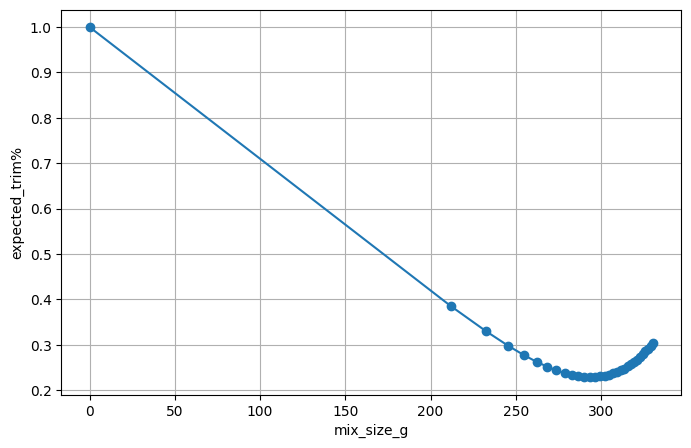

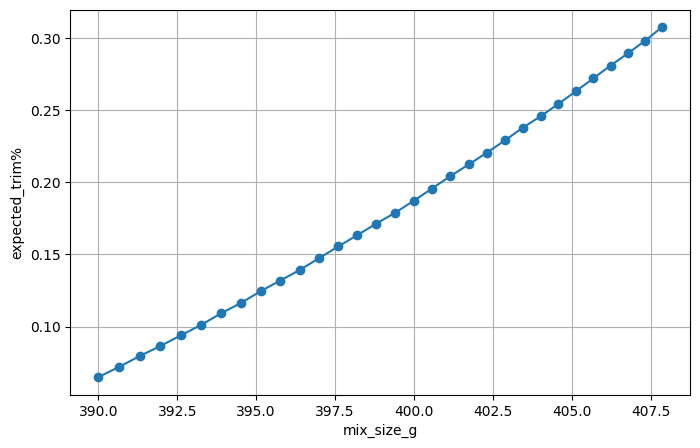

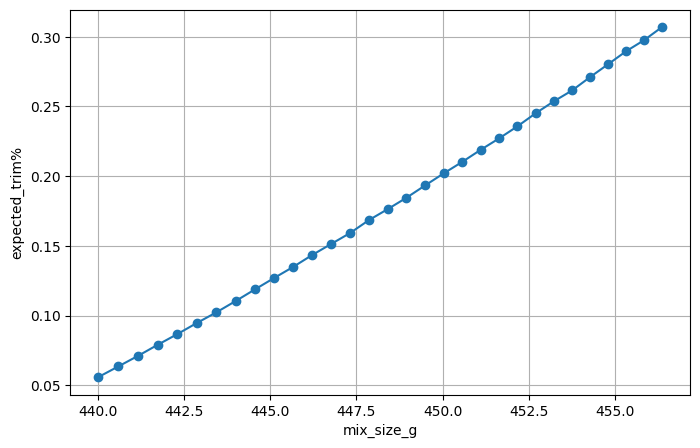

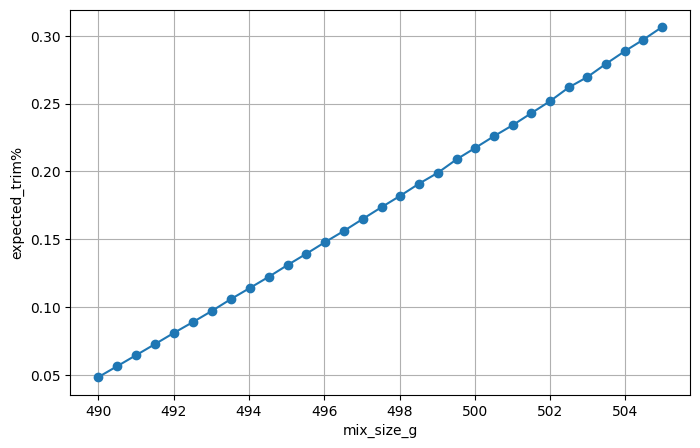

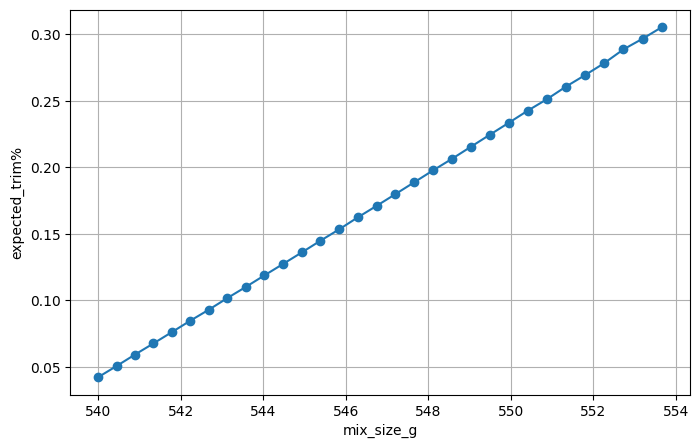

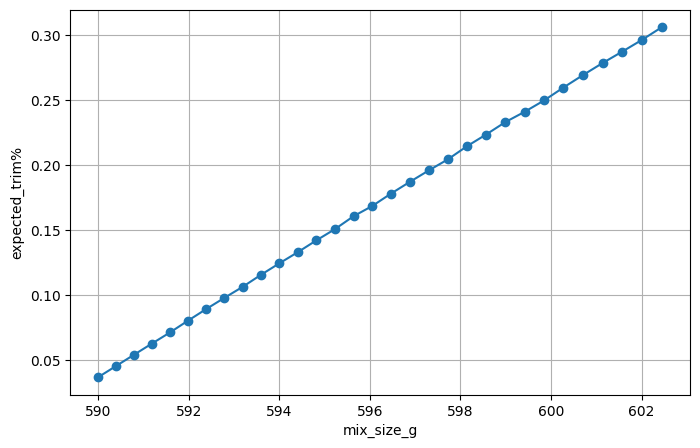

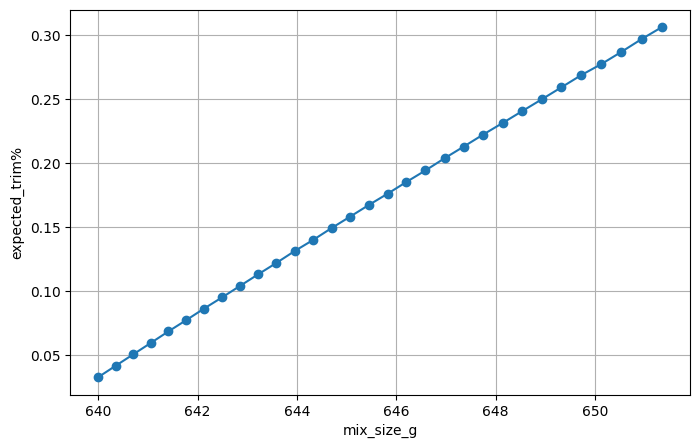

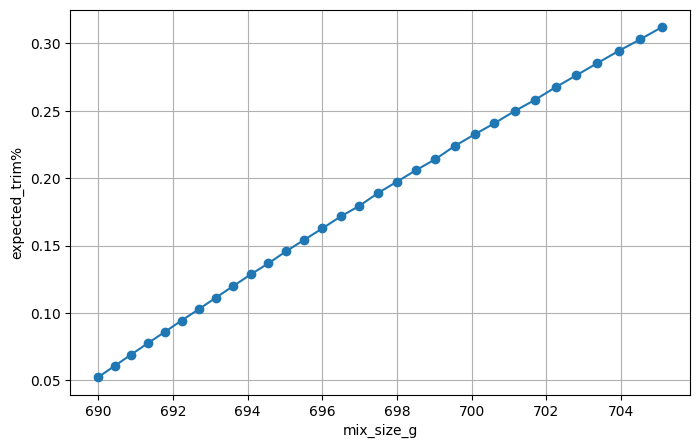

In [57]:
miscut_values = np.arange(0.00, 0.31, 0.01)

# Store everything here
all_results = {}

for label, (low, high) in ranges.items():

    label_results = {}
    trim_list = []
    size_list = []

    for m in miscut_values:
        est_mean, ci_hw, mix_size_g, miscut_pct, expected_trim = mc_miscut_simulation(
            mu, sigma, low, high, accepted_miscut_percentage=m
        )

        label_results[m] = {
            "estimated_mean": est_mean,
            "95%_CI_halfwidth": ci_hw,
            "mix_size_g": mix_size_g,
            "miscut_%": miscut_pct,
            "expected_trim%": expected_trim,
        }

        size_list.append(mix_size_g)
        trim_list.append(expected_trim)

    # Save per-label results
    all_results[label] = label_results

    # ---- Plot for this label ----
    plt.figure(figsize=(8, 5))
    plt.plot(size_list, trim_list, marker="o")
    plt.xlabel("mix_size_g")
    plt.ylabel("expected_trim%")
    # plt.title(f"Expected Trim vs Target Size (Miscut Sweep 0–0.30) — {label}")
    plt.grid(True)
    plt.show()

# Print all results as JSON
# print(json.dumps(all_results, indent=2))
